# Conditional vertical motion using separate spin-up and state files

This notebook expects two NetCDF files in the same directory:

- `run_<case>.nc`: regular production `state` output;
- `run_<case>_spinup.nc`: the spin-up-end snapshot used as production \(T=0\).

It creates:

1. a **1×3 conditional vertical-velocity figure at \(T=0\)** from the spin-up file;
2. a **3×3 conditional-divergence figure at labelled times \(T=0,7,13\) days**.

The \(T=0\) row is taken only from the spin-up file. The later rows are selected from the state file at the stored times nearest 7 and 13 days after the spin-up snapshot. The actual state indices and elapsed times are printed below the figure.

In [9]:
from pathlib import Path
import sys
import importlib
import json
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in (PROJECT_DIR, FLOW_SCRIPTS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(shu)
shu.apply_plot_style()

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
case_name = "run_aug1"
RUN_TITLE_INFO = "Case AUG-1 Production"

STATE_FILE = (NB_DIR / f"../data/input/{case_name}.nc").resolve()
SPINUP_FILE = STATE_FILE.with_name(f"{STATE_FILE.stem}_spinup{STATE_FILE.suffix}")

OUT_DIR = (NB_DIR / f"../results/{case_name}").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
DOMAIN_JSON = OUT_DIR / f"{case_name}_domain_characterization.json"

SAVE = True
DX = 500.0
DY = 500.0
F0 = 8.0e-5

# Labels shown in the figure. The state file provides the nearest stored
# records to 7 and 13 days after the spin-up snapshot.
PLOT_DAYS = [0.0, 7.0, 13.0]
STATE_TARGET_DAYS = [7.0, 13.0]

TARGET_MLD_LABELS = ["0", "0.5", "1"]
NEAR_SURFACE_UV_INDEX = 1
NEAR_SURFACE_W_INDEX = 1
NBINS = 90
MIN_BIN_COUNT = 8
PERCENTILE_LIMIT = 98
W_TO_M_PER_DAY = True

DELR = np.array([
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.2, 2.4, 2.6, 2.9, 3.1,
    3.4, 3.7, 4.0, 4.4, 4.8,
    5.2, 5.7, 6.2, 6.8, 7.4,
    8.1, 8.8, 9.6, 10.5, 11.4,
    12.5, 13.6, 14.8, 16.2, 17.6,
    19.2, 21.0, 22.9, 24.9, 27.2,
    29.7, 32.4, 35.4, 38.6, 42.1,
    45.9, 50.0, 54.5, 59.4, 64.8,
    70.6, 77.0, 84.0, 91.5, 99.7,
    108.7, 118.5, 129.1, 140.8, 153.5,
    167.3, 182.4, 198.8, 216.7, 236.2,
    257.5, 280.7, 306.1, 328.5,
], dtype=float)

UV_DEPTHS_M = np.cumsum(DELR) - 0.5 * DELR
W_DEPTHS_M = np.concatenate(([0.0], np.cumsum(DELR)))

plt.rcParams.update({
    "font.size": 17,
    "axes.titlesize": 19,
    "axes.labelsize": 19,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "figure.titlesize": 22,
})

for path in (STATE_FILE, SPINUP_FILE, DOMAIN_JSON):
    if not path.exists():
        raise FileNotFoundError(path)

with DOMAIN_JSON.open("r", encoding="utf-8") as f:
    MLD_MEAN_M = float(json.load(f)["mld_mean_m"])

print(f"State file  : {STATE_FILE}")
print(f"Spin-up file: {SPINUP_FILE}")
print(f"Mean MLD    : {MLD_MEAN_M:.2f} m")

State file  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1.nc
Spin-up file: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_spinup.nc
Mean MLD    : 16.81 m


In [10]:
# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def open_case(path):
    ds = xr.open_dataset(path, chunks="auto")
    time_dim = shu.find_dim(ds.dims, ["T", "time", "iter"])
    z_dim = shu.find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])
    w_dim = (
        shu.find_dim(ds["WVEL"].dims, ["Zl", "Z", "Zmd", "k", "depth"])
        if "WVEL" in ds else None
    )
    return ds, time_dim, z_dim, w_dim


def time_seconds(ds, time_dim):
    values = np.asarray(ds[time_dim].values)
    units = str(ds[time_dim].attrs.get("units", "")).lower()

    if np.issubdtype(values.dtype, np.datetime64):
        return np.asarray((values - values[0]) / np.timedelta64(1, "s"), dtype=float)
    if np.issubdtype(values.dtype, np.timedelta64):
        return np.asarray(values / np.timedelta64(1, "s"), dtype=float)

    values = values.astype(float)
    if "day" in units:
        return values * 86400.0
    if "hour" in units:
        return values * 3600.0
    return values  # MITgcm numeric clock used here is in seconds


def uv_depths_for(ds, z_dim):
    n = ds.sizes[z_dim]
    if n > UV_DEPTHS_M.size:
        raise ValueError("U/V dataset has more vertical levels than DELR defines.")
    return UV_DEPTHS_M[:n]


def w_depths_for(ds, w_dim):
    n = ds.sizes[w_dim]
    if n > W_DEPTHS_M.size:
        raise ValueError("WVEL dataset has more vertical levels than DELR defines.")
    return W_DEPTHS_M[:n]


def nearest_index(depths, target, min_index=0):
    return int(np.argmin(np.abs(depths[min_index:] - target)) + min_index)


def select_uv_indices(depths):
    return [
        NEAR_SURFACE_UV_INDEX,
        nearest_index(depths, 0.5 * MLD_MEAN_M, NEAR_SURFACE_UV_INDEX),
        nearest_index(depths, 1.0 * MLD_MEAN_M, NEAR_SURFACE_UV_INDEX),
    ]


def select_w_indices(depths):
    return [
        NEAR_SURFACE_W_INDEX,
        nearest_index(depths, 0.5 * MLD_MEAN_M, NEAR_SURFACE_W_INDEX),
        nearest_index(depths, 1.0 * MLD_MEAN_M, NEAR_SURFACE_W_INDEX),
    ]


def usable_uv_record(ds, time_dim, z_dim, it, uv_indices):
    """
    Check whether UVEL and VVEL contain usable data at all selected levels.

    UVEL and VVEL are checked separately because MITgcm stores them on
    different staggered C-grid faces, so their native shapes need not match.
    """
    for k in uv_indices:
        u = shu.clean_fill(
            ds["UVEL"].isel({time_dim: it, z_dim: k}).values
        )
        v = shu.clean_fill(
            ds["VVEL"].isel({time_dim: it, z_dim: k}).values
        )

        valid_u = np.isfinite(u)
        valid_v = np.isfinite(v)

        # Reject empty or almost completely missing records.
        if valid_u.mean() < 0.1 or valid_v.mean() < 0.1:
            return False

        if not valid_u.any() or not valid_v.any():
            return False

        u_std = np.nanstd(u[valid_u])
        v_std = np.nanstd(v[valid_v])

        # Reject unfilled records represented by constant zeros.
        if (
            not np.isfinite(u_std)
            or not np.isfinite(v_std)
            or (u_std <= 1.0e-14 and v_std <= 1.0e-14)
        ):
            return False

    return True


def select_spinup_record(ds, time_dim, z_dim, uv_indices):
    valid = [
        it for it in range(ds.sizes[time_dim])
        if usable_uv_record(ds, time_dim, z_dim, it, uv_indices)
    ]
    if not valid:
        raise ValueError("The spin-up file contains no usable U/V record.")
    return valid[-1]  # spin-up-end snapshot


def select_state_record(ds, time_dim, z_dim, uv_indices, start_time_s, target_day):
    times_s = time_seconds(ds, time_dim)
    valid = np.array([
        it for it in range(ds.sizes[time_dim])
        if usable_uv_record(ds, time_dim, z_dim, it, uv_indices)
    ], dtype=int)
    if valid.size == 0:
        raise ValueError("The state file contains no usable U/V records.")

    elapsed_days = (times_s[valid] - start_time_s) / 86400.0
    position = int(np.argmin(np.abs(elapsed_days - target_day)))
    it = int(valid[position])
    return it, float(elapsed_days[position]), float(times_s[it])


def compute_kinematics(ds, time_dim, z_dim, it, kuv):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)
        ro, div_f, strain = shu.compute_surface_kinematics(
            ds, time_dim, z_dim, it, [kuv], DX, DY, F0
        )
    if not (np.isfinite(ro).any() and np.isfinite(div_f).any() and np.isfinite(strain).any()):
        raise ValueError(f"No finite kinematics at time index {it}, depth index {kuv}.")
    return ro, div_f, strain


def common_edges(fields):
    ro_all = np.concatenate([ro[np.isfinite(ro)] for ro, _, _ in fields])
    st_all = np.concatenate([st[np.isfinite(st)] for _, st, _ in fields])
    x0, x1 = np.nanpercentile(ro_all, [0.2, 99.8])
    y0, y1 = np.nanpercentile(st_all, [0.2, 99.8])
    xpad = 0.04 * (x1 - x0)
    ypad = 0.04 * (y1 - y0)
    return (
        np.linspace(x0 - xpad, x1 + xpad, NBINS + 1),
        np.linspace(max(0.0, y0 - ypad), y1 + ypad, NBINS + 1),
    )


def conditioned_mean(ro, strain, value, ro_edges, strain_edges):
    value, ro, strain = shu.crop_to_common_shape(value, ro, strain)
    mask = np.isfinite(value) & np.isfinite(ro) & np.isfinite(strain)
    mean, count = shu.conditioned_mean_2d(
        ro[mask], strain[mask], value[mask], ro_edges, strain_edges
    )
    mean = np.asarray(mean, dtype=float)
    mean[count < MIN_BIN_COUNT] = np.nan
    return mean


def shared_symmetric_limit(fields):
    finite = [np.abs(a[np.isfinite(a)]) for a in fields if np.isfinite(a).any()]
    if not finite:
        return 1.0
    limit = np.nanpercentile(np.concatenate(finite), PERCENTILE_LIMIT)
    return 1.0 if not np.isfinite(limit) or limit == 0 else float(limit)


def draw_panel(ax, field, x_edges, y_edges, limit, title=""):
    pcm = ax.pcolormesh(
        x_edges, y_edges, field.T,
        shading="auto", cmap=shu.get_cmap("conditional"),
        vmin=-limit, vmax=limit,
    )
    xx = np.linspace(x_edges[0], x_edges[-1], 500)
    ax.plot(xx, np.abs(xx), "--", color=shu.get_color("reference"), lw=1.5, alpha=0.8)
    shu.add_regime_labels(ax, x_edges, y_edges)
    shu.format_axis(ax, title=title, grid=True, equal=False)
    return pcm

In [11]:
# ------------------------------------------------------------
# OPEN FILES AND SELECT SNAPSHOTS
# ------------------------------------------------------------
ds_spin, time_spin, z_spin, w_spin = open_case(SPINUP_FILE)
ds_state, time_state, z_state, _ = open_case(STATE_FILE)

uv_depths_spin = uv_depths_for(ds_spin, z_spin)
uv_depths_state = uv_depths_for(ds_state, z_state)
uv_indices_spin = select_uv_indices(uv_depths_spin)
uv_indices_state = select_uv_indices(uv_depths_state)

it_spin = select_spinup_record(ds_spin, time_spin, z_spin, uv_indices_spin)
spinup_time_s = float(time_seconds(ds_spin, time_spin)[it_spin])

state_selection = [
    select_state_record(
        ds_state, time_state, z_state, uv_indices_state,
        spinup_time_s, target_day,
    )
    for target_day in STATE_TARGET_DAYS
]

print("Snapshot selection")
print(
    f"  Plot T=0 d  <- spin-up index {it_spin}, "
    f"raw model time {spinup_time_s:.0f} s"
)
for target, (it, actual_day, raw_time_s) in zip(STATE_TARGET_DAYS, state_selection):
    print(
        f"  Plot T={target:g} d <- state index {it}, "
        f"raw model time {raw_time_s:.0f} s, "
        f"actual elapsed time {actual_day:.5f} d, "
        f"offset {actual_day - target:+.5f} d"
    )

Snapshot selection
  Plot T=0 d  <- spin-up index 0, raw model time 840640 s
  Plot T=7 d <- state index 3, raw model time 1555200 s, actual elapsed time 8.27037 d, offset +1.27037 d
  Plot T=13 d <- state index 5, raw model time 2073600 s, actual elapsed time 14.27037 d, offset +1.27037 d


In [12]:
# # ------------------------------------------------------------
# # FIGURE 1: CONDITIONAL SIGNED W AT T=0 FROM THE SPIN-UP FILE
# # ------------------------------------------------------------
# if w_spin is None:
#     raise KeyError("WVEL is absent from the spin-up file.")

# w_depths_spin = w_depths_for(ds_spin, w_spin)
# w_indices_spin = select_w_indices(w_depths_spin)

# raw_w = []
# for kuv, kw in zip(uv_indices_spin, w_indices_spin):
#     ro, _, strain = compute_kinematics(ds_spin, time_spin, z_spin, it_spin, kuv)
#     w = shu.clean_fill(ds_spin["WVEL"].isel({time_spin: it_spin, w_spin: kw}).values)
#     if W_TO_M_PER_DAY:
#         w = w * 86400.0
#     raw_w.append((ro, strain, w))

# ro_edges_w, strain_edges_w = common_edges(raw_w)
# W_cond = [conditioned_mean(ro, strain, w, ro_edges_w, strain_edges_w) for ro, strain, w in raw_w]
# w_limit = shared_symmetric_limit(W_cond)

# fig = plt.figure(figsize=(19.5, 6.4), facecolor="white")
# gs = fig.add_gridspec(
#     1, 4, width_ratios=[1, 1, 1, 0.045],
#     left=0.06, right=0.96, bottom=0.13, top=0.78, wspace=0.16,
# )
# axes = [fig.add_subplot(gs[0, j]) for j in range(3)]
# cax = fig.add_subplot(gs[0, 3])

# for j, (ax, field) in enumerate(zip(axes, W_cond)):
#     pcm = draw_panel(
#         ax, field, ro_edges_w, strain_edges_w, w_limit,
#         title=rf"$z/\mathrm{{MLD}}\approx {TARGET_MLD_LABELS[j]}$",
#     )
#     ax.set_xlabel(r"$\zeta/f_0$")
#     if j == 0:
#         ax.set_ylabel(r"$\sigma/|f_0|$")
#     else:
#         ax.tick_params(labelleft=False)

# cbar = fig.colorbar(pcm, cax=cax, extend="both")
# cbar.set_label(
#     r"$\overline{w}^{\,\zeta\sigma}$ [m day$^{-1}$]"
#     if W_TO_M_PER_DAY else r"$\overline{w}^{\,\zeta\sigma}$ [m s$^{-1}$]"
# )
# fig.suptitle(f"Conditional mean vertical velocity at T = 0 days ({RUN_TITLE_INFO})", y=0.96)
# shu.savefig_if_needed(
#     fig, f"conditional_w_t0_spinup_three_mld_depths_{case_name}",
#     save=SAVE, out_dir=OUT_DIR,
# )
# plt.show()

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\conditional_divergence_spinup_state_3x3_mld_run_aug1.png


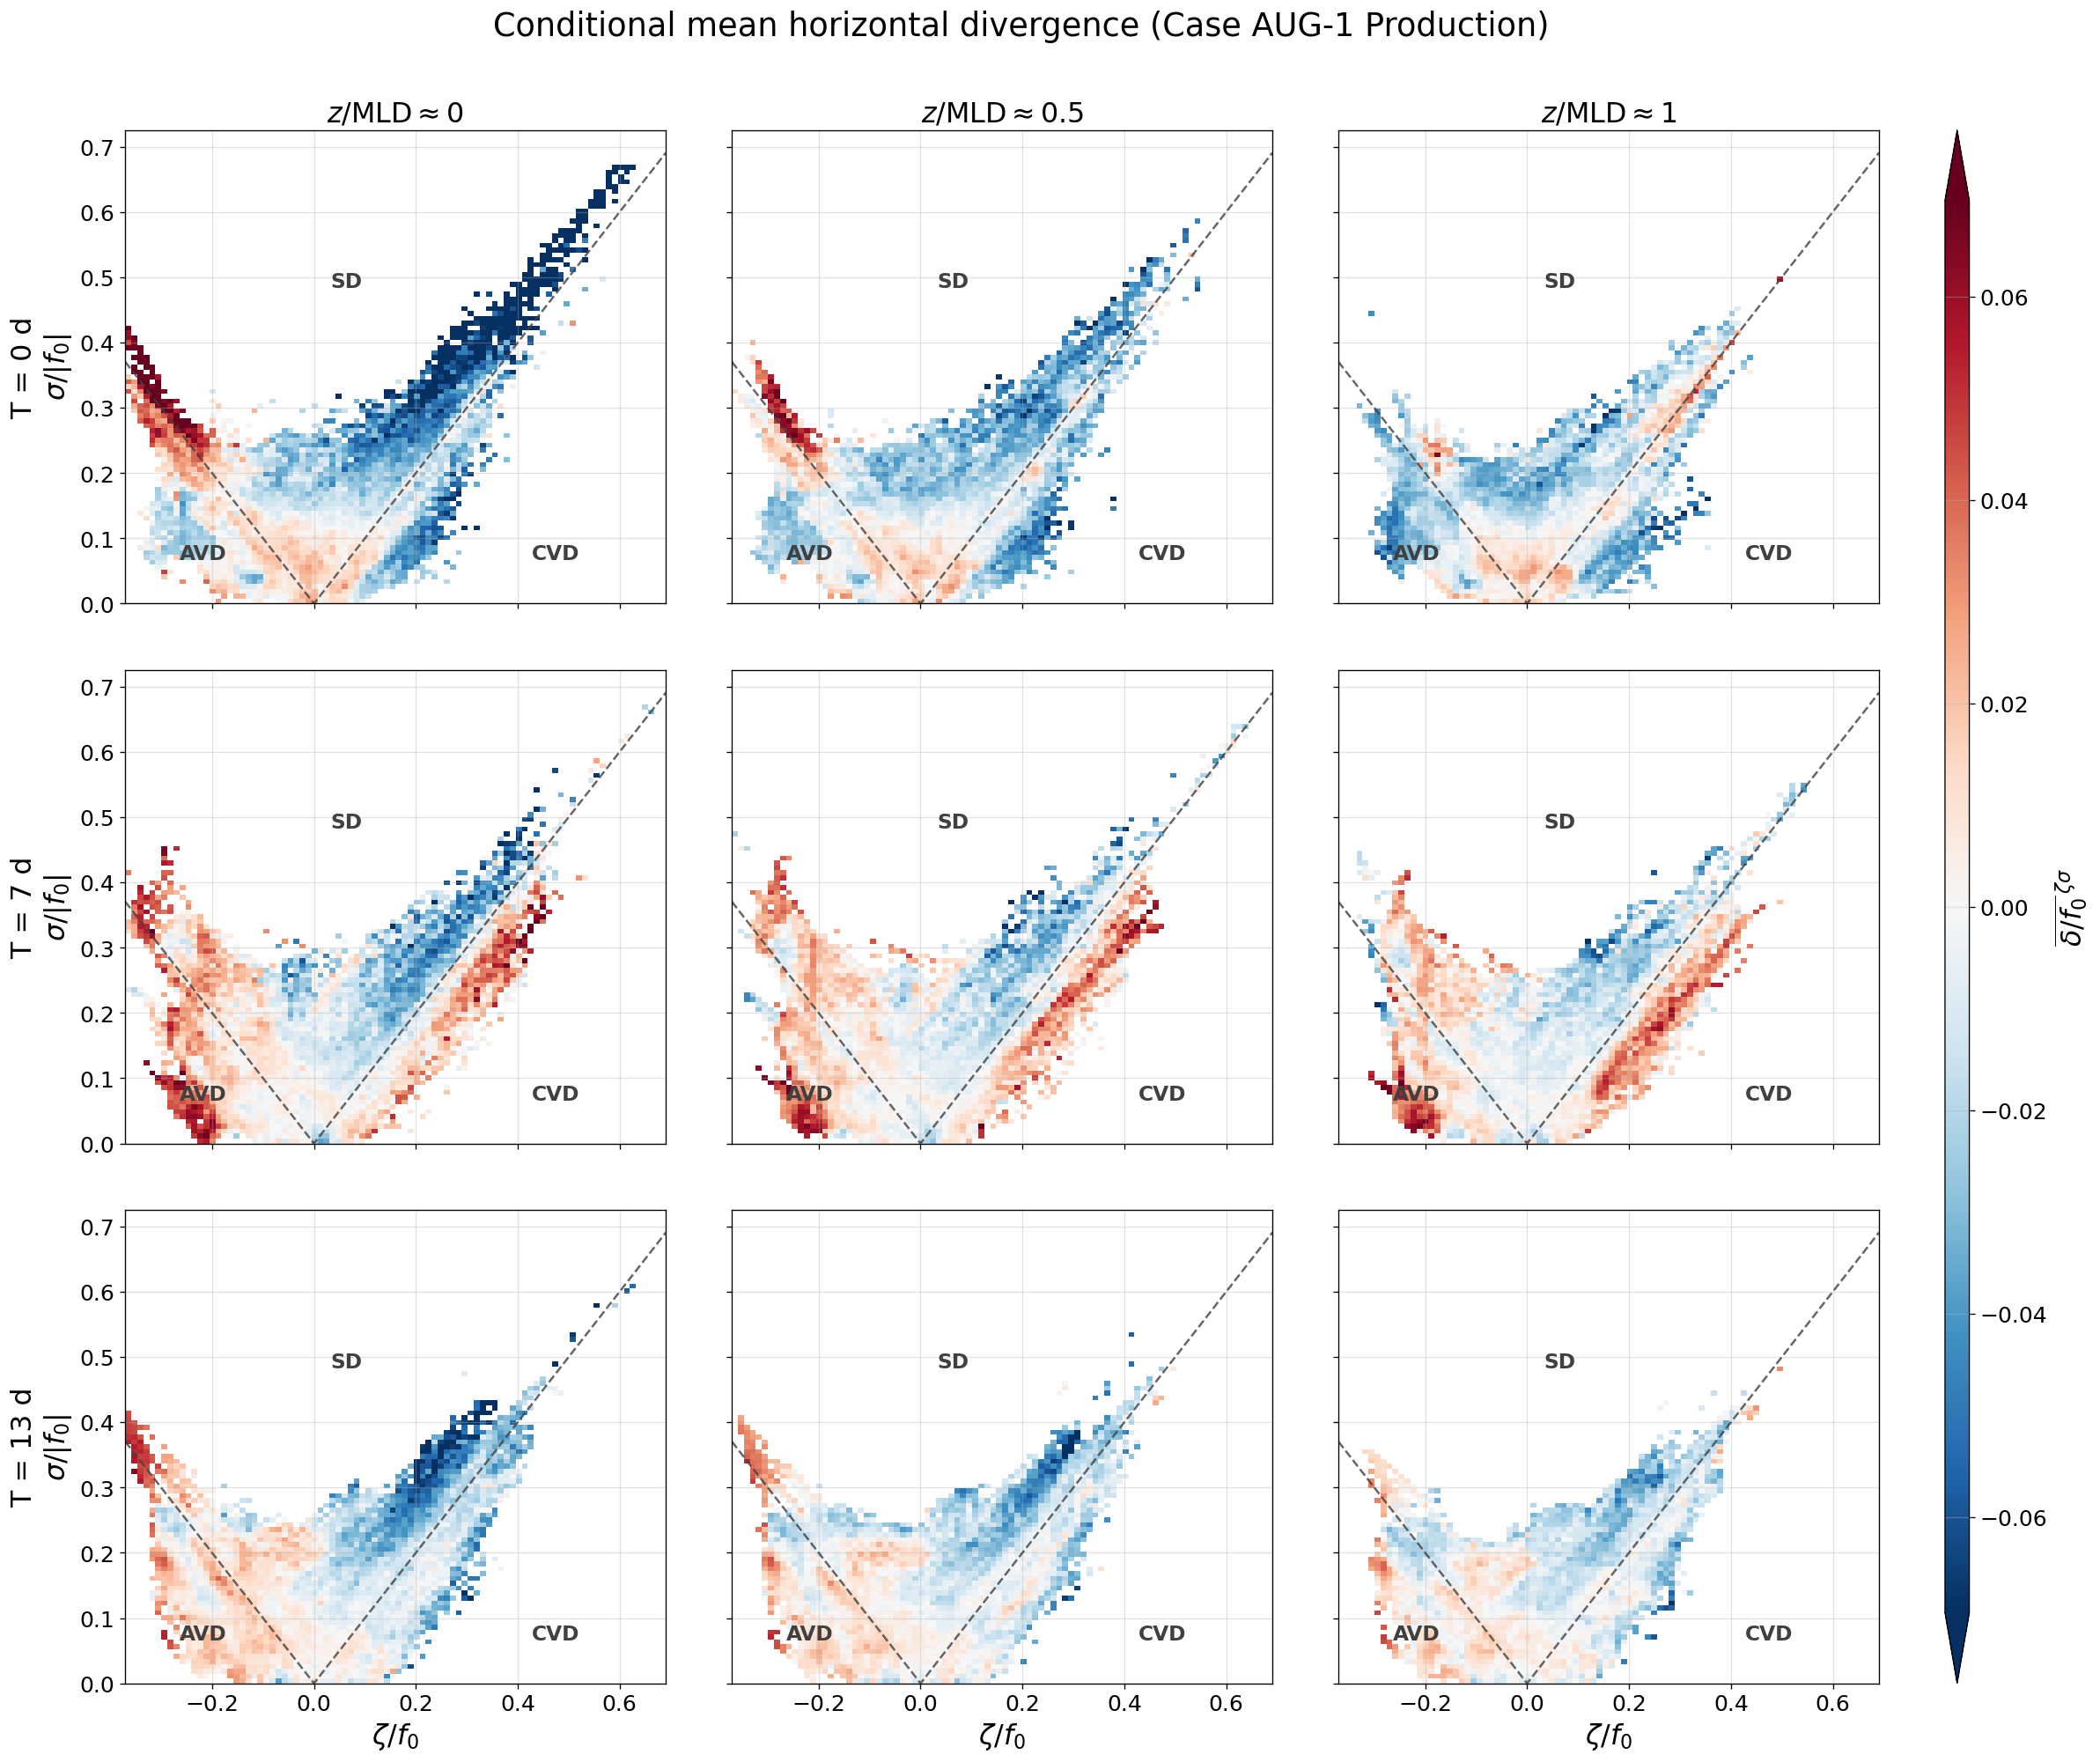


Actual records used for the state rows
  Label T=7 d: state index=3, raw time=1555200 s, actual elapsed=8.27037 d
  Label T=13 d: state index=5, raw time=2073600 s, actual elapsed=14.27037 d


In [13]:
# ------------------------------------------------------------
# FIGURE 2: CONDITIONAL DIVERGENCE AT LABELLED T=0, 7, 13 DAYS
# ------------------------------------------------------------
snapshots = [
    {
        "ds": ds_spin,
        "time_dim": time_spin,
        "z_dim": z_spin,
        "uv_indices": uv_indices_spin,
        "it": it_spin,
        "plot_day": 0.0,
        "actual_day": 0.0,
        "source": "spin-up",
    }
]

for target, (it, actual_day, _) in zip(STATE_TARGET_DAYS, state_selection):
    snapshots.append({
        "ds": ds_state,
        "time_dim": time_state,
        "z_dim": z_state,
        "uv_indices": uv_indices_state,
        "it": it,
        "plot_day": target,
        "actual_day": actual_day,
        "source": "state",
    })

raw_d = []
for snapshot in snapshots:
    for col, kuv in enumerate(snapshot["uv_indices"]):
        ro, div_f, strain = compute_kinematics(
            snapshot["ds"], snapshot["time_dim"], snapshot["z_dim"],
            snapshot["it"], kuv,
        )
        raw_d.append((ro, strain, div_f, snapshot["plot_day"], snapshot["actual_day"], col))

ro_edges_d, strain_edges_d = common_edges([(ro, strain, div) for ro, strain, div, *_ in raw_d])
D_cond = [
    conditioned_mean(ro, strain, div, ro_edges_d, strain_edges_d)
    for ro, strain, div, *_ in raw_d
]
d_limit = shared_symmetric_limit(D_cond)

fig = plt.figure(figsize=(19.5, 17.5), facecolor="white")
gs = fig.add_gridspec(
    3, 4, width_ratios=[1, 1, 1, 0.045],
    left=0.065, right=0.96, bottom=0.07, top=0.91,
    wspace=0.16, hspace=0.14,
)
axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(3)])
cax = fig.add_subplot(gs[:, 3])

for index, (field, (_, _, _, plot_day, actual_day, col)) in enumerate(zip(D_cond, raw_d)):
    row = index // 3
    ax = axes[row, col]
    title = rf"$z/\mathrm{{MLD}}\approx {TARGET_MLD_LABELS[col]}$" if row == 0 else ""
    pcm = draw_panel(ax, field, ro_edges_d, strain_edges_d, d_limit, title=title)

    if row == 2:
        ax.set_xlabel(r"$\zeta/f_0$")
    else:
        ax.tick_params(labelbottom=False)

    if col == 0:
        ax.set_ylabel(rf"T = {plot_day:g} d" + "\n" + r"$\sigma/|f_0|$")
    else:
        ax.tick_params(labelleft=False)

cbar = fig.colorbar(pcm, cax=cax, extend="both")
cbar.set_label(r"$\overline{\delta/f_0}^{\,\zeta\sigma}$")
fig.suptitle(f"Conditional mean horizontal divergence ({RUN_TITLE_INFO})", y=0.975)
shu.savefig_if_needed(
    fig, f"conditional_divergence_spinup_state_3x3_mld_{case_name}",
    save=SAVE, out_dir=OUT_DIR,
)
plt.show()

print("\nActual records used for the state rows")
for target, (it, actual_day, raw_time_s) in zip(STATE_TARGET_DAYS, state_selection):
    print(
        f"  Label T={target:g} d: state index={it}, "
        f"raw time={raw_time_s:.0f} s, actual elapsed={actual_day:.5f} d"
    )